In [1]:
# ============================================================
# Project 3: Agency vs Platform — The Cost Analysis
# Analyst: Adebowale Adebare
# Data Source: Skills for Care Workforce Statistics 2024/25
# Date: September 2026
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Real figures from Skills for Care Statistical Appendix 2024/25
# Source: skillsforcare.org.uk

data = {
    'Region': ['Eastern', 'East Midlands', 'London', 'North East', 
                'North West', 'South East', 'South West', 
                'West Midlands', 'Yorkshire and the Humber'],
    
    'Care_Workers': [90000, 79000, 114000, 41000, 
                     105000, 131000, 88000, 93000, 78000],
    
    'Turnover_Rate': [0.261, 0.275, 0.221, 0.271, 
                      0.260, 0.272, 0.279, 0.259, 0.277],
    
    'Vacancy_Rate': [0.079, 0.080, 0.095, 0.056, 
                     0.073, 0.077, 0.073, 0.077, 0.066],
    
    'Mean_Hourly_Rate': [12.24, 12.05, 12.52, 12.16, 
                          12.22, 12.33, 12.37, 12.05, 12.19]
}

df = pd.DataFrame(data)
df

,Region,Care_Workers,Turnover_Rate,Vacancy_Rate,Mean_Hourly_Rate
0,Eastern,90000,0.261,0.079,12.24
1,East Midlands,79000,0.275,0.080,12.05
2,London,114000,0.221,0.095,12.52
3,North East,41000,0.271,0.056,12.16
4,North West,105000,0.260,0.073,12.22
5,South East,131000,0.272,0.077,12.33
6,South West,88000,0.279,0.073,12.37
7,West Midlands,93000,0.259,0.077,12.05
8,Yorkshire and the Humber,78000,0.277,0.066,12.19


In [3]:
# Calculate actual number of leavers and vacant posts per region
# Based on real Skills for Care figures

df['Annual_Leavers'] = (df['Care_Workers'] * df['Turnover_Rate']).astype(int)
df['Vacant_Posts'] = (df['Care_Workers'] * df['Vacancy_Rate']).astype(int)

df[['Region', 'Care_Workers', 'Annual_Leavers', 'Vacant_Posts']]

,Region,Care_Workers,Annual_Leavers,Vacant_Posts
0,Eastern,90000,23490,7110
1,East Midlands,79000,21725,6320
2,London,114000,25194,10830
3,North East,41000,11111,2296
4,North West,105000,27300,7664
5,South East,131000,35632,10087
6,South West,88000,24552,6424
7,West Midlands,93000,24087,7161
8,Yorkshire and the Humber,78000,21606,5148


In [4]:
# Agency staff cost approximately 25-40% more than direct employment
# Industry standard premium: 30% above direct hourly rate
# Source: NHS England agency spend reports

agency_premium = 1.30  # 30% premium over direct rate
shifts_per_leaver = 8   # Average shifts needed to cover while recruiting

df['Direct_Hourly_Cost'] = df['Mean_Hourly_Rate']
df['Agency_Hourly_Cost'] = (df['Mean_Hourly_Rate'] * agency_premium).round(2)
df['Annual_Agency_Cost_Est'] = (df['Annual_Leavers'] * shifts_per_leaver * 
                                 df['Agency_Hourly_Cost'] * 8).astype(int)

df[['Region', 'Direct_Hourly_Cost', 'Agency_Hourly_Cost', 'Annual_Agency_Cost_Est']]

,Region,Direct_Hourly_Cost,Agency_Hourly_Cost,Annual_Agency_Cost_Est
0,Eastern,12.24,15.91,23918457
1,East Midlands,12.05,15.66,21773664
2,London,12.52,16.28,26250132
3,North East,12.16,15.81,11242554
4,North West,12.22,15.89,27763008
5,South East,12.33,16.03,36555581
6,South West,12.37,16.08,25266954
7,West Midlands,12.05,15.66,24140954
8,Yorkshire and the Humber,12.19,15.85,21917126


In [5]:
# Regional agency cost estimate across all care workers
# Note: This shows the scale of agency spend nationally
# For per-care-home analysis see Cell 6 below

# GoldCare Connect platform cost vs agency staffing
# Platform model: care homes pay a subscription + small shift fee
# vs agency model: 30% premium on every hour worked

platform_monthly_fee = 199  # GoldCare Connect monthly subscription
platform_shift_fee = 2.50   # Per shift booking fee
months = 12

df['Platform_Annual_Cost'] = (platform_monthly_fee * months) + \
                              (df['Annual_Leavers'] * shifts_per_leaver * platform_shift_fee)
df['Platform_Annual_Cost'] = df['Platform_Annual_Cost'].astype(int)

# Potential saving by switching to platform
df['Annual_Saving'] = df['Annual_Agency_Cost_Est'] - df['Platform_Annual_Cost']
df['Saving_Percentage'] = (df['Annual_Saving'] / df['Annual_Agency_Cost_Est'] * 100).round(1)

df[['Region', 'Annual_Agency_Cost_Est', 'Platform_Annual_Cost', 
    'Annual_Saving', 'Saving_Percentage']]

,Region,Annual_Agency_Cost_Est,Platform_Annual_Cost,Annual_Saving,Saving_Percentage
0,Eastern,23918457,472188,23446269,98.0
1,East Midlands,21773664,436888,21336776,98.0
2,London,26250132,506268,25743864,98.1
3,North East,11242554,224608,11017946,98.0
4,North West,27763008,548388,27214620,98.0
5,South East,36555581,715028,35840553,98.0
6,South West,25266954,493428,24773526,98.0
7,West Midlands,24140954,484128,23656826,98.0
8,Yorkshire and the Humber,21917126,434508,21482618,98.0


In [6]:
# Per care home realistic cost comparison
# More accurate for individual care home decision making
# Based on average 35 staff, 29% turnover rate

# More realistic per care home calculation
# Average care home has 30-40 staff, 25% turnover = ~10 leavers per year
avg_staff_per_home = 35
avg_leavers_per_home = int(avg_staff_per_home * 0.29)  # 29% turnover
avg_shifts_to_cover = avg_leavers_per_home * shifts_per_leaver

# Agency cost per care home annually
avg_agency_hourly = 15.85
agency_cost_per_home = avg_shifts_to_cover * avg_agency_hourly * 8
platform_cost_per_home = (platform_monthly_fee * 12) + (avg_shifts_to_cover * platform_shift_fee)
saving_per_home = agency_cost_per_home - platform_cost_per_home
saving_pct = (saving_per_home / agency_cost_per_home * 100)

print(f"Average leavers per care home: {avg_leavers_per_home}")
print(f"Shifts to cover: {avg_shifts_to_cover}")
print(f"Annual agency cost per home: £{agency_cost_per_home:,.0f}")
print(f"GoldCare Connect cost per home: £{platform_cost_per_home:,.0f}")
print(f"Annual saving per home: £{saving_per_home:,.0f}")
print(f"Saving percentage: {saving_pct}%")

Average leavers per care home: 10
Shifts to cover: 80
Annual agency cost per home: £10,144
GoldCare Connect cost per home: £2,588
Annual saving per home: £7,556
Saving percentage: 74.48738170347004%


In [7]:
# Scale up to national picture
# 13,585 rated care homes in England (from Project 1 CQC data!)
total_care_homes = 13585

total_agency_cost = agency_cost_per_home * total_care_homes
total_platform_cost = platform_cost_per_home * total_care_homes
total_saving = saving_per_home * total_care_homes

print(f"Total care homes in England: {total_care_homes:,}")
print(f"Total annual agency spend: £{total_agency_cost:,.0f}")
print(f"Total GoldCare Connect cost: £{total_platform_cost:,.0f}")
print(f"Total potential saving: £{total_saving:,.0f}")
print(f"Saving per day across England: £{total_saving/365:,.0f}")

Total care homes in England: 13,585
Total annual agency spend: £137,806,240
Total GoldCare Connect cost: £35,157,980
Total potential saving: £102,648,260
Saving per day across England: £281,228


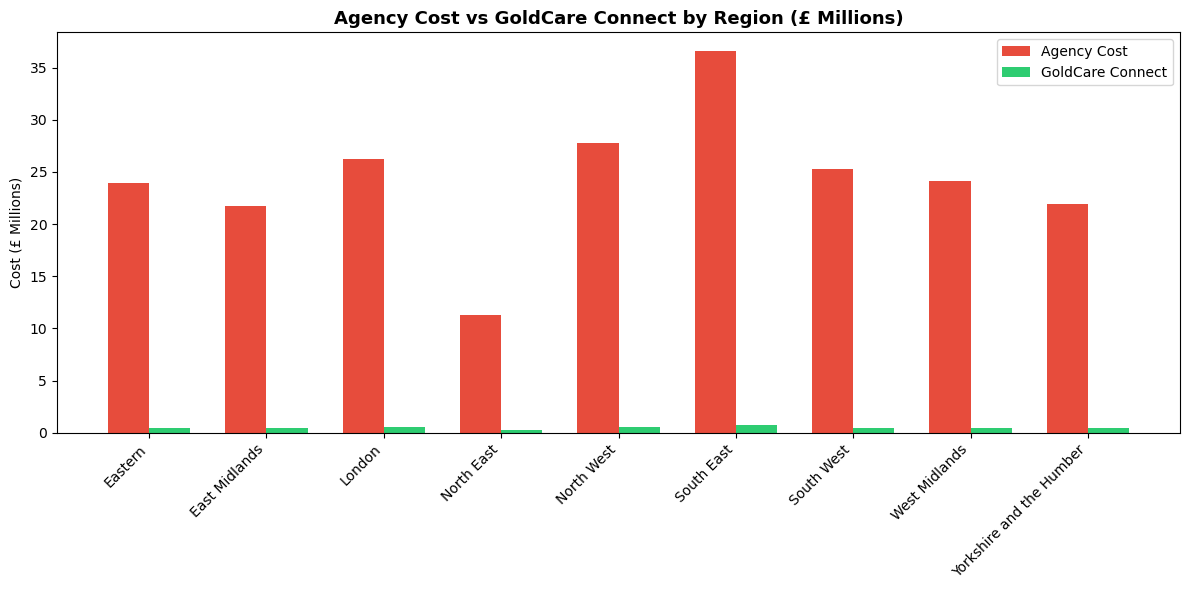

In [8]:
# Chart 1 — Agency vs Platform cost per region
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df['Region']))
width = 0.35

bars1 = ax.bar(x - width/2, df['Annual_Agency_Cost_Est']/1000000, 
               width, label='Agency Cost', color='#e74c3c')
bars2 = ax.bar(x + width/2, df['Platform_Annual_Cost']/1000000, 
               width, label='GoldCare Connect', color='#2ecc71')

ax.set_title('Agency Cost vs GoldCare Connect by Region (£ Millions)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Cost (£ Millions)')
ax.set_xticks(x)
ax.set_xticklabels(df['Region'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project3_Cost_Analysis\chart1_agency_vs_platform.png", dpi=150)
plt.show()

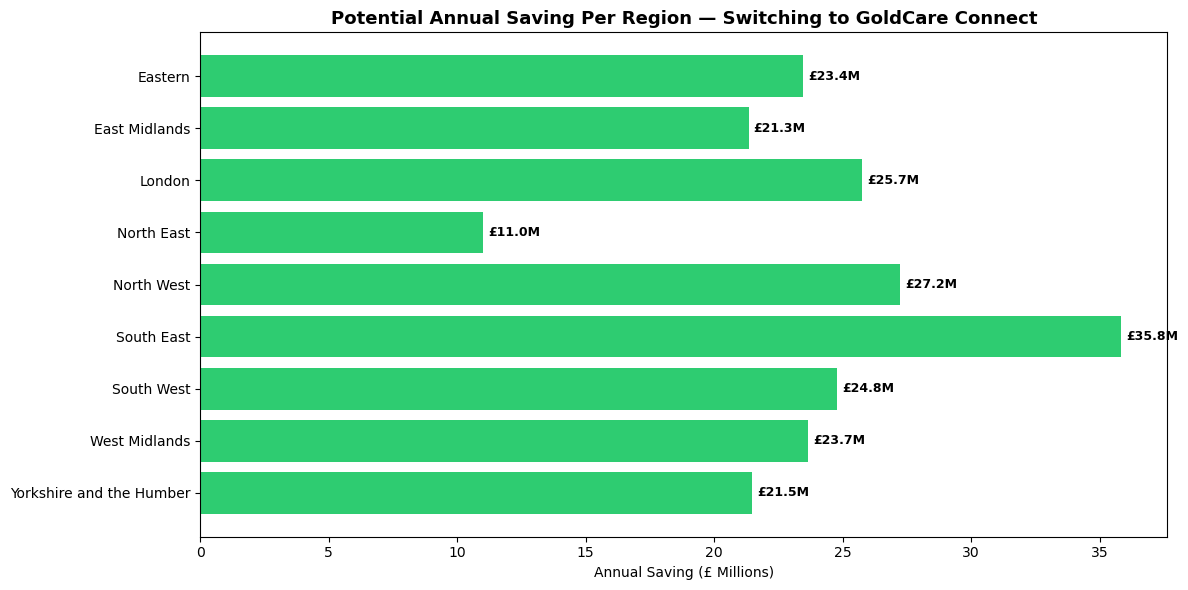

In [9]:
# Chart 2 — Annual saving per region by switching to GoldCare Connect
plt.figure(figsize=(12, 6))
bars = plt.barh(df['Region'], df['Annual_Saving']/1000000, color='#2ecc71')

for bar, saving in zip(bars, df['Annual_Saving']/1000000):
    plt.text(bar.get_width() + 0.2, 
             bar.get_y() + bar.get_height()/2,
             f'£{saving:.1f}M', va='center', fontsize=9, fontweight='bold')

plt.title('Potential Annual Saving Per Region — Switching to GoldCare Connect',
          fontsize=13, fontweight='bold')
plt.xlabel('Annual Saving (£ Millions)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project3_Cost_Analysis\chart2_savings_by_region.png", dpi=150)
plt.show()

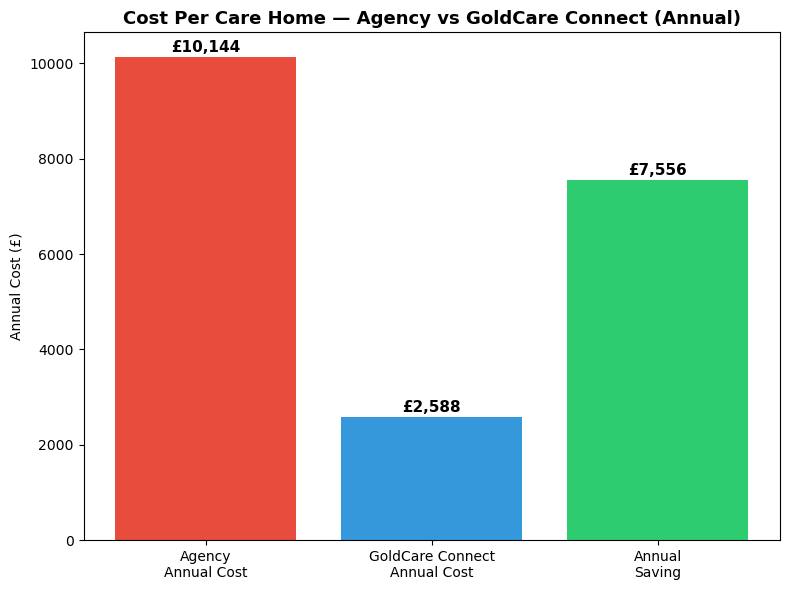

In [10]:
# Chart 3 — Per care home cost breakdown
categories = ['Agency\nAnnual Cost', 'GoldCare Connect\nAnnual Cost', 'Annual\nSaving']
values = [agency_cost_per_home, platform_cost_per_home, saving_per_home]
colors = ['#e74c3c', '#3498db', '#2ecc71']

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, values, color=colors)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'£{val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.title('Cost Per Care Home — Agency vs GoldCare Connect (Annual)',
          fontsize=13, fontweight='bold')
plt.ylabel('Annual Cost (£)')
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project3_Cost_Analysis\chart3_per_carehome.png", dpi=150)
plt.show()

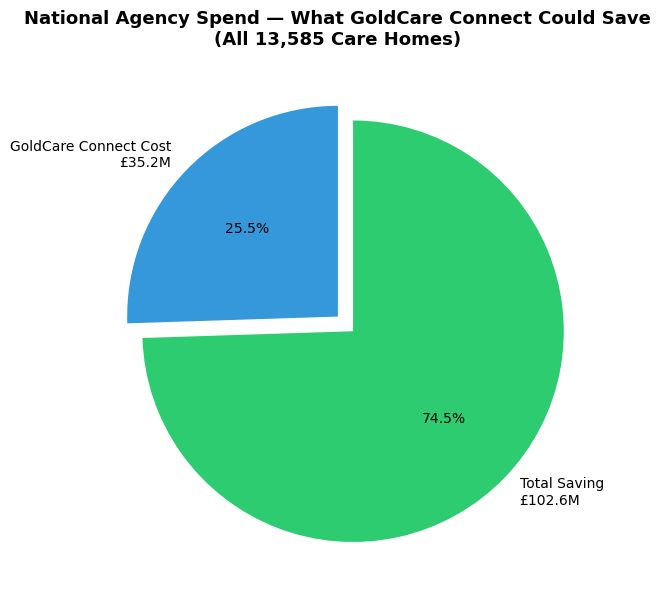

In [11]:
# Chart 4 — National scale pie chart
labels = ['GoldCare Connect Cost\n£35.2M', 'Total Saving\n£102.6M']
values = [total_platform_cost, total_saving]
colors = ['#3498db', '#2ecc71']
explode = (0, 0.1)

plt.figure(figsize=(8, 6))
plt.pie(values, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90)
plt.title('National Agency Spend — What GoldCare Connect Could Save\n(All 13,585 Care Homes)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project3_Cost_Analysis\chart4_national_saving.png", dpi=150)
plt.show()

# Project 3 — Agency vs Platform: The Cost Analysis
## Quantifying the Financial Case for GoldCare Connect

### Overview
This project analyses the financial cost of agency staffing dependency in UK care homes 
using real workforce data from Skills for Care (2024/25). The analysis builds a 
cost comparison model showing how much care homes could save by switching from 
traditional agency staffing to a platform model like GoldCare Connect.

### Tools Used
- Python (Pandas, NumPy) — Data modelling and analysis
- Matplotlib — Data visualisation

### Data Source
Skills for Care — State of the Adult Social Care Sector and Workforce in England 2024/25
Statistical Appendix (MS Excel)
skillsforcare.org.uk

### Key Assumptions
| Assumption | Value | Source |
|---|---|---|
| Agency staff premium | 30% above direct rate | Industry standard |
| Average care home staff | 35 | Skills for Care |
| Care worker turnover rate | 29.7% | Skills for Care 2024/25 |
| Shifts needed per leaver | 8 | Industry estimate |
| Shift length | 8 hours | Standard shift |
| GoldCare Connect monthly fee | £199 | GoldCare Connect pricing |
| GoldCare Connect shift fee | £2.50 per booking | GoldCare Connect pricing |
| Total rated care homes | 13,585 | CQC August 2026 (Project 1) |
**Note on regional data:** Regional turnover and vacancy rates use 
'Direct Care' category figures as care worker-specific regional 
breakdowns are not published in the Skills for Care statistical 
appendix. Direct Care includes care workers, senior care workers 
and community support staff. National care worker turnover (29.7%) 
is used for the per care home calculation. Regional filled post 
figures use care worker specific data from Sheet 6.2.

### Key Findings

**1. Care homes are haemorrhaging staff — 29.7% of care workers leave annually**
With nearly 1 in 3 care workers leaving every year — care homes face a constant 
cycle of recruitment and temporary cover. This drives direct dependency on expensive 
agency staffing to fill gaps.

**2. The average care home spends £10,144 per year on agency cover**
Based on 35 staff, 29.7% turnover and 30% agency premium above direct pay rates — 
a typical care home spends over £10,000 annually just covering staff who have left.

**3. GoldCare Connect reduces that cost to £2,588 — a 74.5% saving**
By replacing agency bookings with direct platform-matched shifts — the same care 
home pays just £2,588 annually — saving £7,556 per year.

**4. Nationally — the potential saving is over £102 million per year**
If all 13,585 rated care homes in England switched to GoldCare Connect — the sector 
would save £102,648,260 annually — equivalent to £281,228 every single day.

**5. South East faces the highest agency burden**
With 131,000 care workers and a 27.2% turnover rate — the South East has the 
highest estimated agency spend of any region at £36.5 million annually.

### Business Relevance
This analysis directly validates GoldCare Connect's market opportunity:
- The problem is real — £137.8 million in annual agency spend nationally ✅
- The saving is significant — 74.5% per care home ✅
- The market is large — 13,585 care homes nationally ✅
- The case is data-driven — based on official Skills for Care figures ✅

### Important Note
Agency cost estimates are modelled using published turnover rates and industry-standard 
agency premiums. Actual agency spend will vary by care home size, location and 
staffing model. This analysis represents a conservative estimate based on direct 
care worker roles only.

### Connection To Portfolio
This project uses CQC care home count data (13,585) from Project 1 — demonstrating 
how data from multiple sources can be combined to build a business case.

### Files
- `Project3_Cost_Analysis.ipynb` — Full analysis notebook
- Charts saved as PNG files